In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler,LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer

In [6]:
df=pd.read_csv("/content/drive/My Drive/Colab Notebooks/Machine Learning/heart_disease_risk_2026.csv")
print("Dataset loaded successfully")

Dataset loaded successfully


In [13]:
df.shape

(9000, 30)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 9000 non-null   int64  
 1   age                        9000 non-null   int64  
 2   sex                        9000 non-null   object 
 3   resting_bp_systolic        9000 non-null   int64  
 4   resting_bp_diastolic       9000 non-null   int64  
 5   cholesterol_total          9000 non-null   int64  
 6   hdl                        9000 non-null   int64  
 7   ldl                        9000 non-null   int64  
 8   triglycerides              9000 non-null   int64  
 9   fasting_blood_sugar        9000 non-null   int64  
 10  hba1c                      9000 non-null   float64
 11  bmi                        9000 non-null   float64
 12  resting_heart_rate         9000 non-null   int64  
 13  max_heart_rate_achieved    9000 non-null   int64

In [ ]:
df.dtypes

,0
patient_id,int64
age,int64
sex,object
resting_bp_systolic,int64
resting_bp_diastolic,int64
cholesterol_total,int64
hdl,int64
ldl,int64
triglycerides,int64
fasting_blood_sugar,int64


In [ ]:
df.describe()

,patient_id,age,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,hba1c,...,resting_heart_rate,max_heart_rate_achieved,st_depression,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,daily_steps,diet_quality_score,has_heart_disease
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,...,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,4500.500000,53.977333,127.849778,80.788778,188.753556,55.215333,103.275556,152.045000,119.470444,5.791633,...,80.912667,164.838333,1.012911,5.708733,139.493444,6.994578,47.968033,6163.659333,59.467400,0.303000
std,2598.220545,13.008051,13.767233,10.939943,32.271644,12.394400,27.342198,51.448384,22.778082,0.692645,...,8.604685,21.290773,0.957090,5.070642,63.660433,1.104215,16.162484,2170.685995,14.476064,0.459581
min,1.000000,18.000000,85.000000,50.000000,90.000000,18.000000,35.000000,35.000000,60.000000,4.000000,...,48.000000,93.000000,0.000000,0.000000,0.000000,3.100000,0.000000,500.000000,4.800000,0.000000
25%,2250.750000,45.000000,119.000000,74.000000,167.000000,47.000000,85.000000,117.000000,104.000000,5.300000,...,75.000000,150.000000,0.400000,2.200000,96.000000,6.300000,37.100000,4658.000000,49.700000,0.000000
50%,4500.500000,54.000000,128.000000,81.000000,189.000000,55.000000,103.000000,151.000000,119.000000,5.800000,...,81.000000,166.000000,0.700000,4.200000,139.000000,7.000000,48.100000,6178.000000,59.600000,0.000000
75%,6750.250000,63.000000,137.000000,88.000000,211.000000,64.000000,122.000000,186.000000,135.000000,6.300000,...,87.000000,180.000000,1.400000,7.700000,183.000000,7.700000,58.900000,7632.750000,69.100000,1.000000
max,9000.000000,90.000000,181.000000,126.000000,314.000000,110.000000,207.000000,390.000000,204.000000,8.600000,...,111.000000,210.000000,6.500000,45.900000,366.000000,11.000000,100.000000,13950.000000,100.000000,1.000000


In [ ]:
df.isnull().sum()

,0
patient_id,0
age,0
sex,0
resting_bp_systolic,0
resting_bp_diastolic,0
cholesterol_total,0
hdl,0
ldl,0
triglycerides,0
fasting_blood_sugar,0


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
drop_columns=['patient_id','wearable_owner']
df.drop(drop_columns,axis=1,inplace=True)
print("Columns dropped successfully")

Columns dropped successfully


In [9]:
# Apply one-hot encoding
df = pd.get_dummies(df, columns=['chest_pain_type'], dtype=int)
le=LabelEncoder()
df['sex']=le.fit_transform(df['sex'])
df['exercise_induced_angina']=le.fit_transform(df['exercise_induced_angina'])
df['family_history']=le.fit_transform(df['family_history'])
df['smoker_status']=le.fit_transform(df['smoker_status'])
df.head()

,patient_id,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,...,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease,chest_pain_type_Asymptomatic,chest_pain_type_Atypical Angina,chest_pain_type_Non-Anginal Pain,chest_pain_type_Typical Angina
0,1,44,1,117,74,193,57,106,119,112,...,5.4,19.8,True,7731,62.9,0,1,0,0,0
1,2,57,1,139,94,185,69,110,35,114,...,4.3,45.8,True,2629,74.6,1,0,0,1,0
2,3,29,1,128,78,197,52,108,157,95,...,5.1,17.7,True,9290,65.7,0,1,0,0,0
3,4,72,1,132,86,197,59,104,143,92,...,6.8,63.6,True,7373,48.5,1,1,0,0,0
4,5,62,0,116,75,154,65,75,104,135,...,8.2,58.7,False,6331,47.3,1,0,1,0,0


In [10]:
numerical_cols = [
    'age', 'resting_bp_systolic', 'resting_bp_diastolic', 'cholesterol_total',
    'hdl', 'ldl', 'triglycerides', 'fasting_blood_sugar', 'hba1c', 'bmi',
    'resting_heart_rate', 'max_heart_rate_achieved', 'st_depression',
    'alcohol_units_per_week', 'exercise_minutes_per_week', 'sleep_hours',
    'stress_score', 'daily_steps', 'diet_quality_score'
]

scaler = MinMaxScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
print("Normalization completed successfully on numeric columns")

Normalization completed successfully on numeric columns


In [11]:
print("After Preprocessing")
df.head(10)

After Preprocessing


,patient_id,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,...,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease,chest_pain_type_Asymptomatic,chest_pain_type_Atypical Angina,chest_pain_type_Non-Anginal Pain,chest_pain_type_Typical Angina
0,1,0.361111,1,0.333333,0.315789,0.459821,0.423913,0.412791,0.236620,0.361111,...,0.291139,0.198,True,0.537621,0.610294,0,1,0,0,0
1,2,0.541667,1,0.562500,0.578947,0.424107,0.554348,0.436047,0.000000,0.375000,...,0.151899,0.458,True,0.158290,0.733193,1,0,0,1,0
2,3,0.152778,1,0.447917,0.368421,0.477679,0.369565,0.424419,0.343662,0.243056,...,0.253165,0.177,True,0.653532,0.639706,0,1,0,0,0
3,4,0.750000,1,0.489583,0.473684,0.477679,0.445652,0.401163,0.304225,0.222222,...,0.468354,0.636,True,0.511004,0.459034,1,1,0,0,0
4,5,0.611111,0,0.322917,0.328947,0.285714,0.510870,0.232558,0.194366,0.520833,...,0.645570,0.587,False,0.433532,0.446429,1,0,1,0,0
5,6,0.444444,0,0.385417,0.276316,0.254464,0.304348,0.383721,0.016901,0.513889,...,0.354430,0.551,False,0.472639,0.817227,0,0,1,0,0
6,7,0.444444,0,0.500000,0.460526,0.611607,0.489130,0.517442,0.447887,0.340278,...,0.645570,0.822,True,0.592268,0.618697,0,0,0,1,0
7,8,0.555556,0,0.500000,0.407895,0.227679,0.391304,0.372093,0.014085,0.402778,...,0.417722,0.455,True,0.466097,0.394958,1,1,0,0,0
8,9,0.458333,0,0.375000,0.184211,0.575893,0.717391,0.401163,0.140845,0.527778,...,0.746835,0.656,True,0.531450,0.511555,0,1,0,0,0
9,10,0.458333,1,0.427083,0.355263,0.366071,0.347826,0.401163,0.225352,0.500000,...,0.759494,0.587,False,0.522751,0.508403,0,1,0,0,0


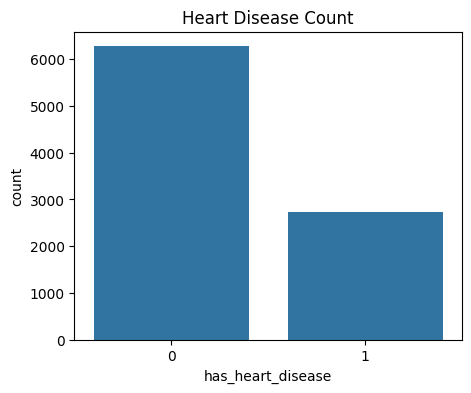

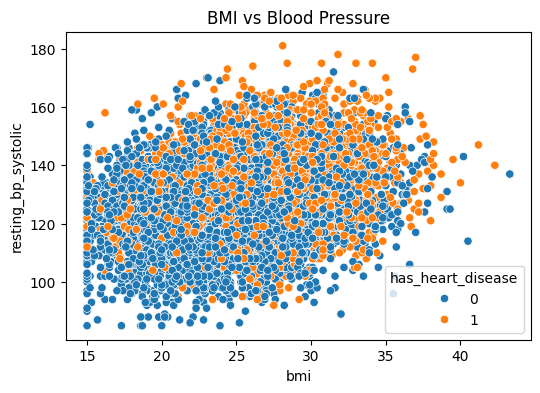

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

y = df['has_heart_disease']

plt.figure(figsize=(5, 4))
sns.countplot(x=y)
plt.title("Heart Disease Count")
plt.show()

plt.figure(figsize=(6, 4))
sns.scatterplot(x=df["bmi"], y=df["resting_bp_systolic"], hue=y)
plt.title("BMI vs Blood Pressure")
plt.show()